In [1]:
%load_ext autoreload
%autoreload 2

save_plot = False

In [2]:
import sys
sys.path.append('..')
import pandas as pd 
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from results_analysis_helper import *
import json
import seaborn as sns

pd.set_option('display.max_rows', 100)

# Tell Matplotlib to export text as text, not paths (editable in Illustrator)
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
# gene_perf = pd.read_parquet(f"/cwork/hl489/Pertb_benchmark/DataSet2/gene_perf_combined_all_methods_detail.parquet")
# gene_2 = pd.read_parquet(f"/cwork/hl489/Pertb_benchmark/DataSet2/geneperf_K562_HCT116_HEK293T_hvg5000_detail.parquet")

In [4]:
# Get perturbations present in every dataset
# datasets = gene_perf['dataset'].unique()
# common_perts = gene_perf.groupby('perturbation')['dataset'].nunique()
# common_perts = common_perts[common_perts == len(datasets)].index

# gene_2 = gene_2[gene_2['perturbation'].isin(common_perts)]
# gene_perf = gene_perf[~gene_perf.dataset.isin(['K562', 'HEK293T', 'HCT116'])]
# gene_perf = pd.concat([gene_perf, gene_2])

In [5]:
# gene_perf.groupby('dataset')['perturbation'].nunique()


In [18]:
# new_metrics = compute_new_corr_metrics(
#     gene_perf,
#     deg=[1000, 2000, 5000],
#     sign_tau=0.0,
#     updown_tau=0.0,
#     de_frac=0.1,
#     topk_values=(100,),
    
# )

new_metrics = pd.read_parquet("new_metrics_large_all.parquet")
new_metrics['DataSet'] = new_metrics['DataSet'].replace({
    'HCT_large': 'HCT116',
    'HEK_large': 'HEK293T',
    'K562_large': 'K562',
    'hepg2_large': 'HepG2',
    'jurkat_large': 'Jurkat',
    'rpe1_large': 'RPE1',
})

keep_metrics = [
    'pearson_distance_raw', 'spearman_distance_raw',
    'pearson_distance_delta', 'spearman_distance_delta',
    'mean_absolute_error_delta', 'mean_squared_error_delta',
    'root_mean_squared_error_delta','sign_error_delta', 'topk_jaccard_distance_delta_k100', "cosine_distance_delta"
]

new_metrics_sub = new_metrics[new_metrics['metric'].isin(keep_metrics)]

expected = (new_metrics_sub['method'].nunique()
            * new_metrics_sub['DataSet'].nunique()
            * new_metrics_sub['DEG'].nunique()
            * len(keep_metrics))

full_perts = new_metrics_sub.groupby('perturb').filter(
    lambda g: len(g) == expected
)['perturb'].unique()

new_metrics1 = new_metrics_sub[new_metrics_sub['perturb'].isin(full_perts)]
print(f"Kept {len(full_perts)} / {new_metrics_sub['perturb'].nunique()} perturbations, "
      f"expected {expected} rows each")




Kept 1912 / 2278 perturbations, expected 900 rows each


In [19]:
METHOD_ORDER = ['trainMean', 'scGPT', 'GEARS', 'CPA']

PALETTE = {
    'trainMean': '#f0027f',
    'scouter': '#7fc97f',
    'scGPT': '#beaed4',
    'GEARS': '#fdc086',
    'CPA': '#ffff99',
    
    
}

SHORT_NAMES = {
    'pearson_distance_delta':       'Pearson\nDelta',
    'spearman_distance_delta':      'Spearman\nDelta',
    'cosine_distance_delta':        'Cosine',
    'mean_absolute_error_delta':    'MAE',
    'sign_error_delta':             'Sign Error',
    'updown_f1_distance_delta':     'Up/Down F1',
    'de_auroc_distance_delta':      'DE AUROC',
    'de_auprc_distance_delta':      'DE AUPRC',
    'topk_jaccard_distance_delta_k100':  'Top-100\nJaccard',
    'topk_precision_distance_delta_k100': 'Top-100 Precision',
    'ccc_delta':                    'CCC',
}
SHORT_NAMES['mean_squared_error_delta'] = 'MSE'
SHORT_NAMES['pearson_distance_raw'] = 'Pearson (raw)'
SHORT_NAMES['spearman_distance_raw'] = 'Spearman (raw)'
SHORT_NAMES['spearman_distance_raw'] = 'Spearman\nDistance'
SHORT_NAMES['root_mean_squared_error_delta'] = 'RMSE'


In [20]:
from scipy.stats import wilcoxon
from itertools import combinations
from scipy.stats import ttest_rel

subset = new_metrics1[
    new_metrics1.metric.isin(["pearson_distance_delta", "spearman_distance_delta", "topk_jaccard_distance_delta_k100",
    "cosine_distance_delta"])
]

# Per-perturbation scores: median across splits, then mean across datasets
per_pert = (subset.groupby(['perturb', 'method', 'metric', 'DEG', 'DataSet'])['performance']
            .median()
            .groupby(['perturb', 'method', 'metric', 'DEG'])
            .mean()
            .reset_index())

all_tests = []
for deg in [1000, 2000, 5000]:
    for met in per_pert['metric'].unique():
        sub = per_pert[(per_pert.DEG == deg) & (per_pert.metric == met)]
        pivot = sub.pivot(index='perturb', columns='method', values='performance').dropna()

        for m1, m2 in combinations(METHOD_ORDER, 2):
            if m1 not in pivot.columns or m2 not in pivot.columns:
                continue
            # stat, pval = wilcoxon(pivot[m1], pivot[m2], alternative='two-sided')
            stat, pval = ttest_rel(1 - pivot[m1], 1 - pivot[m2])


            all_tests.append({
                'DEG': deg, 'metric': met,
                'method_1': m1, 'method_2': m2,
                'mean_m1': (1 - pivot[m1]).mean(),
                'mean_m2': (1 - pivot[m2]).mean(),

                'W_stat': stat, 'pval': pval,
                'n_pairs': len(pivot),
            })

test_df = pd.DataFrame(all_tests)
test_df['sig'] = test_df['pval'].apply(lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns')



In [34]:
metric_order = ['Pearson\nDelta', 'Spearman\nDelta', 'Top-100\nJaccard', 'Cosine']

In [35]:
all_dfs = []
for deg in [1000, 2000, 5000]:
    results = method_performance_overview(
        subset[subset.DEG == deg],
        common_only=True,
        convert_higher_to_lower=True,
        verbose=False,
    )
    mm = results['method_metric'].loc[METHOD_ORDER].rename(columns=SHORT_NAMES)
    mm = 1 - mm
    mm = mm[metric_order]
    mm['DEG'] = deg
    all_dfs.append(mm)

combined = pd.concat(all_dfs)
display(combined)
# new_metrics1.metric.value_counts()

metric,Pearson\nDelta,Spearman\nDelta,Top-100\nJaccard,Cosine,DEG
method,,,,,
trainMean,0.401813,0.329948,0.339909,0.410253,1000
scGPT,0.287058,0.350221,0.254084,0.281409,1000
GEARS,0.224878,0.233622,0.272503,0.229282,1000
CPA,0.159588,0.113389,0.188995,0.161227,1000
trainMean,0.383743,0.334464,0.214209,0.388842,2000
scGPT,0.261251,0.321046,0.178699,0.259447,2000
GEARS,0.206490,0.202696,0.155221,0.207607,2000
CPA,0.153742,0.108847,0.097834,0.155115,2000
trainMean,0.337116,0.282012,0.153103,0.336911,5000


1912 perturbations


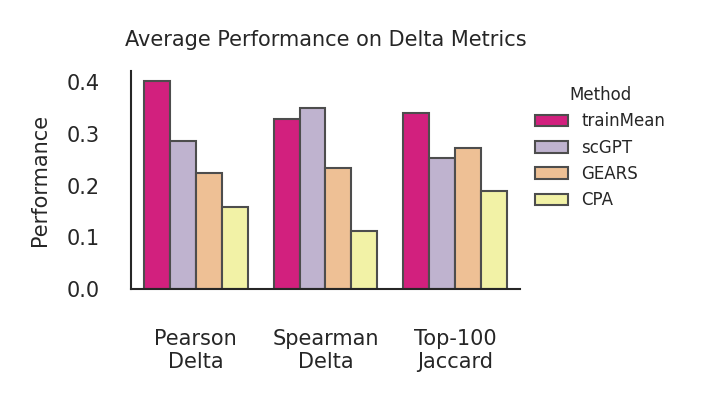

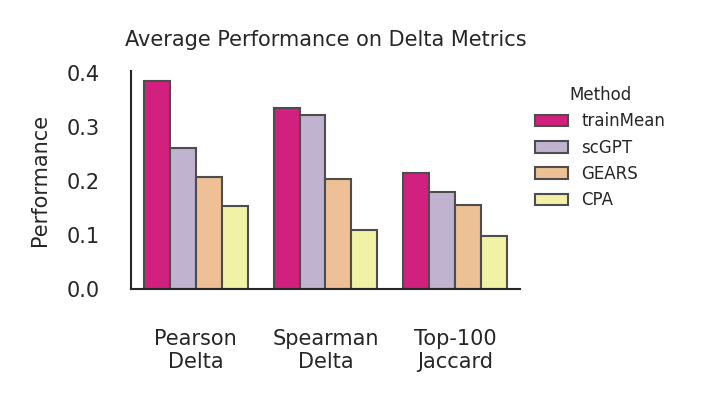

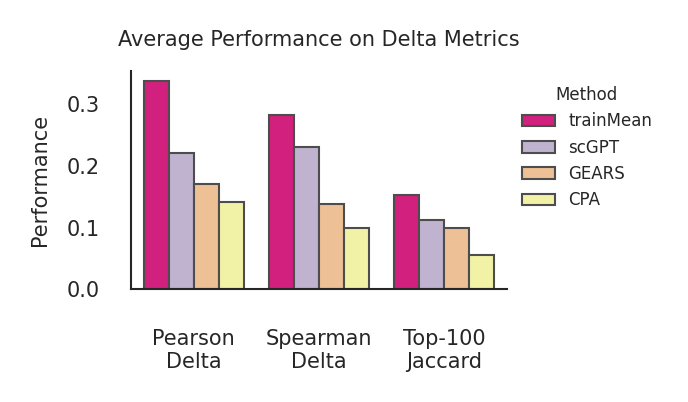

In [22]:
subset = new_metrics1[
    (new_metrics1.metric.isin(["pearson_distance_delta", "spearman_distance_delta", "topk_jaccard_distance_delta_k100", "cosine_distance_delta"]))
]
print(f"{subset['perturb'].nunique()} perturbations")

# metric_order = ['Pearson\nDelta', 'Spearman\nDelta', 'Top-100\nJaccard']

for deg in [1000, 2000, 5000]:
    results = method_performance_overview(
        subset[subset.DEG == deg],
        common_only=True,
        convert_higher_to_lower=True,
        verbose=False,
    )
    # print(f"DEG={deg}: {sub_deg['perturb'].nunique()} perturbations")
    mm = results['method_metric'].loc[METHOD_ORDER].rename(columns=SHORT_NAMES)
    mm = 1 - mm
    mm = mm[metric_order]

    mm_long = mm.reset_index().melt(id_vars='method', var_name='Metric', value_name='Score')
    mm_long['Metric'] = pd.Categorical(mm_long['Metric'], categories=metric_order, ordered=True)

    fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=300)
    sns.set_theme(style="white")
    sns.barplot(data=mm_long, x='Metric', y='Score', hue='method',
                hue_order=METHOD_ORDER, palette=PALETTE, ax=ax,
                edgecolor='0.3', linewidth=0.5)
    ax.set_xlabel('')
    ax.set_ylabel('Performance', fontsize=5)
    ax.set_title(f'Average Performance on Delta Metrics', fontsize=5)
    ax.tick_params(axis='x', rotation=0, labelsize=5)
    ax.tick_params(axis='y', labelsize=5, direction='out', length=4, width=0.8)
    ax.legend(fontsize=4, title_fontsize=4, title='Method', ncol=1,
            bbox_to_anchor=(1.0, 1.0), loc='upper left', frameon=False)
    sns.despine(ax=ax, top=True, right=True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    plt.tight_layout()
    if save_plot:
        plt.savefig(f'Fig1/Fig1B_DEG{deg}.png', bbox_inches='tight', dpi=300)
        plt.savefig(f'Fig1/Fig1B_DEG{deg}.svg', bbox_inches='tight')
    plt.show()

1912 perturbations


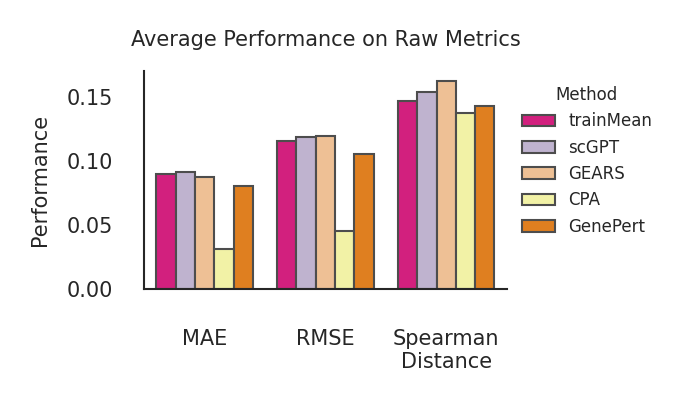

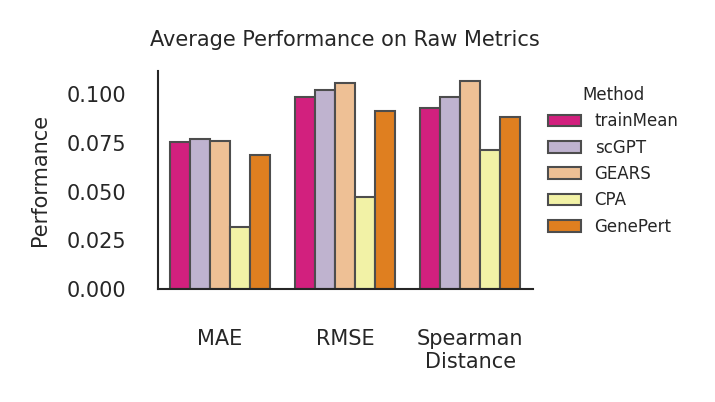

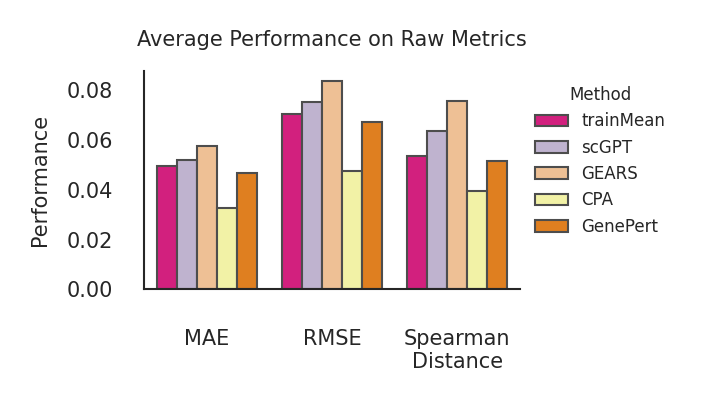

In [47]:
subset = new_metrics1[
    (new_metrics1.metric.isin(["mean_absolute_error_delta", "root_mean_squared_error_delta", "spearman_distance_raw"]))
]
print(f"{subset['perturb'].nunique()} perturbations")
metric_order = ['MAE', 'RMSE', 'Spearman\nDistance']

for deg in [1000, 2000, 5000]:
    results = method_performance_overview(
        subset[subset.DEG == deg],
        common_only=True,
        convert_higher_to_lower=True,
        verbose=False,
    )
    mm = results['method_metric'].loc[METHOD_ORDER].rename(columns=SHORT_NAMES)
    # mm = 1 - mm
    mm = mm[metric_order]

    mm_long = mm.reset_index().melt(id_vars='method', var_name='Metric', value_name='Score')
    mm_long['Metric'] = pd.Categorical(mm_long['Metric'], categories=metric_order, ordered=True)

    fig, ax = plt.subplots(figsize=(2.5, 1.5), dpi=300)
    sns.set_theme(style="white")
    sns.barplot(data=mm_long, x='Metric', y='Score', hue='method',
                hue_order=METHOD_ORDER, palette=PALETTE, ax=ax,
                edgecolor='0.3', linewidth=0.5)
    ax.set_xlabel('')
    ax.set_ylabel('Performance', fontsize=5)
    ax.set_title(f'Average Performance on Raw Metrics', fontsize=5)
    ax.tick_params(axis='x', rotation=0, labelsize=5)
    ax.tick_params(axis='y', labelsize=5, direction='out', length=4, width=0.8)
    ax.legend(fontsize=4, title_fontsize=4, title='Method', ncol=1,
            bbox_to_anchor=(1.0, 1.0), loc='upper left', frameon=False)
    sns.despine(ax=ax, top=True, right=True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    plt.tight_layout()
    if save_plot:
        plt.savefig(f'Fig1/Fig1B_DEG{deg}_mae_mse_raw.png', bbox_inches='tight', dpi=300)
        plt.savefig(f'Fig1/Fig1B_DEG{deg}_mae_mse_raw.svg', bbox_inches='tight')
    plt.show()


In [16]:
subset.groupby('DataSet')['perturb'].nunique()
# subset

DataSet
HCT116     2272
HEK293T    2276
HepG2      2278
Jurkat     2277
K562       2278
RPE1       2278
Name: perturb, dtype: int64

1912 perturbations


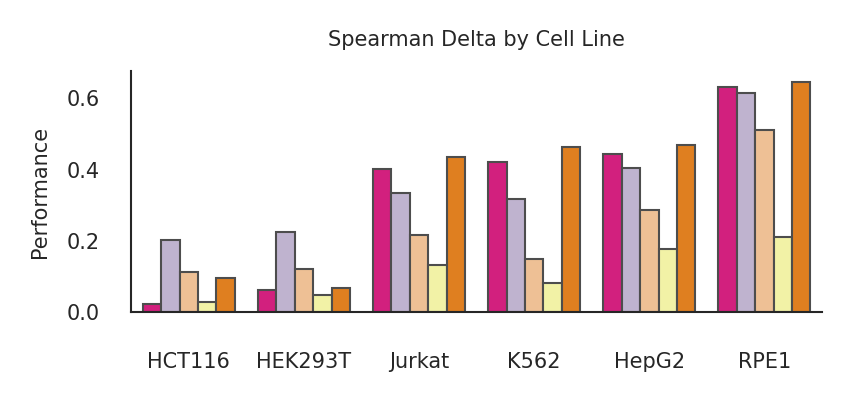

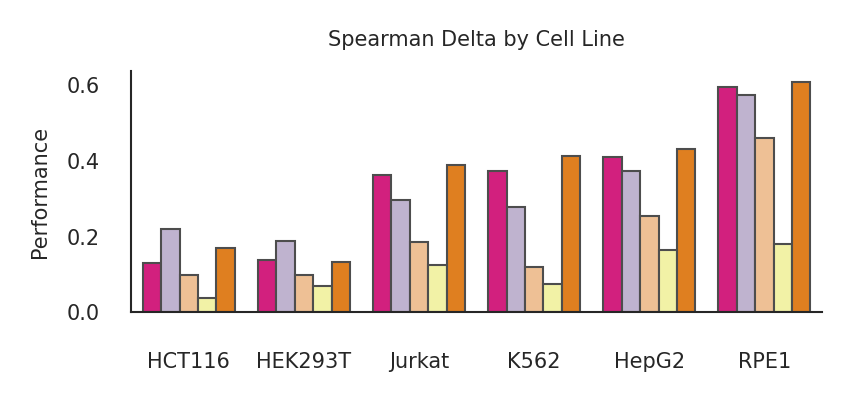

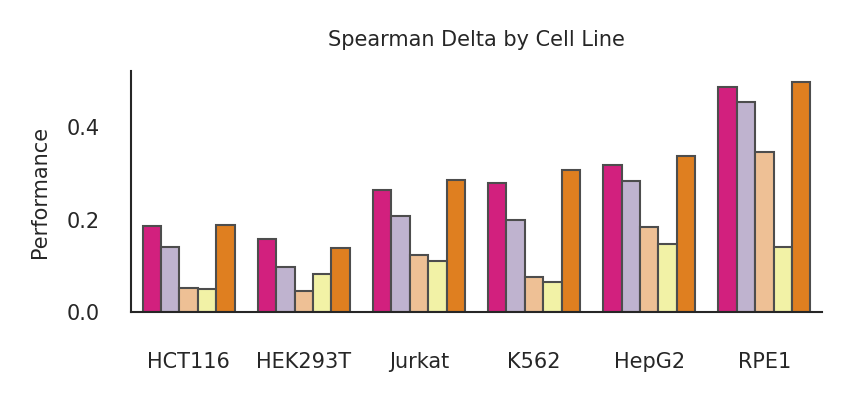

In [50]:
cell_lines_order = ['HCT116', 'HEK293T', 'Jurkat', 'K562', 'HepG2', 'RPE1']

subset = new_metrics1[
    (new_metrics1.metric == "spearman_distance_delta")
]
print(f"{subset['perturb'].nunique()} perturbations")
for deg in [1000, 2000, 5000]:
    sub_deg = subset[subset.DEG == deg]
    
    # Average performance per method x cell line
    agg = sub_deg.groupby(['method', 'DataSet'])['performance'].mean().reset_index()
    agg.columns = ['method', 'Cell Line', 'Score']
    agg['Score'] = 1 - agg['Score']  # convert distance to similarity

    fig, ax = plt.subplots(figsize=(3, 1.5), dpi=300)
    sns.set_theme(style="white")
    sns.barplot(data=agg, x='Cell Line', y='Score', hue='method',
                hue_order=METHOD_ORDER, palette=PALETTE, ax=ax,
                order=cell_lines_order,
                edgecolor='0.3', linewidth=0.5)
    ax.set_xlabel('')
    ax.set_ylabel('Performance', fontsize=5)
    ax.set_title('Spearman Delta by Cell Line', fontsize=5)
    ax.tick_params(axis='x', rotation=0, labelsize=5)
    ax.tick_params(axis='y', labelsize=5, direction='out', length=4, width=0.8)
    ax.legend_.remove()
    sns.despine(ax=ax, top=True, right=True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    plt.tight_layout()
    if save_plot:
        plt.savefig(f'Fig1/Fig1B_DEG{deg}_spearman_by_cellline.png', bbox_inches='tight', dpi=300)
        plt.savefig(f'Fig1/Fig1B_DEG{deg}_spearman_by_cellline.svg', bbox_inches='tight')
    plt.show()


Cell lines: ['HCT116', 'HEK293T', 'HepG2', 'Jurkat', 'K562', 'RPE1']
Common perturbations: 2269
Method=trainMean, Metric=spearman_distance_delta, DEG=2000
Cell lines: ['HCT116', 'HEK293T', 'HepG2', 'Jurkat', 'K562', 'RPE1']
Lower = better | n=2269 common perturbations

TOP 10 BEST PREDICTED (lowest spearman_distance_delta)
DataSet  HCT116  HEK293T   HepG2  Jurkat    K562    RPE1  mean_perf
perturb                                                            
RPL12    0.2494   0.3340  0.0781  0.2559  0.3782  0.0846     0.2300
UTP15    0.2326   0.3537  0.1662  0.1708  0.4185  0.0956     0.2396
MED21    0.3033   0.2556  0.1837  0.2223  0.2974  0.1830     0.2409
EXOSC9   0.1588   0.3622  0.2705  0.2235  0.3663  0.1090     0.2484
WDR75    0.1893   0.2943  0.1343  0.2366  0.5356  0.1260     0.2527
HEATR1   0.2098   0.3536  0.1260  0.2511  0.4174  0.1718     0.2549
EIF2B3   0.2273   0.2828  0.2866  0.3262  0.2226  0.2180     0.2606
EXOSC8   0.2022   0.4862  0.2618  0.2432  0.3131  0.1062     0.

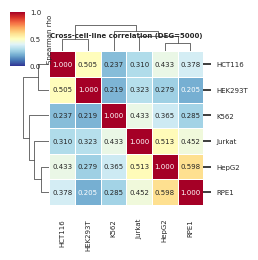

Cell lines: ['HCT116', 'HEK293T', 'HepG2', 'Jurkat', 'K562', 'RPE1']
Common perturbations: 2269
Method=trainMean, Metric=spearman_distance_delta, DEG=1000
Cell lines: ['HCT116', 'HEK293T', 'HepG2', 'Jurkat', 'K562', 'RPE1']
Lower = better | n=2269 common perturbations

TOP 10 BEST PREDICTED (lowest spearman_distance_delta)
DataSet  HCT116  HEK293T   HepG2  Jurkat    K562    RPE1  mean_perf
perturb                                                            
RPL12    0.2019   0.2762  0.0576  0.1461  0.2876  0.0844     0.1756
WDR75    0.1223   0.1876  0.1040  0.1956  0.4335  0.0994     0.1904
EXOSC9   0.1236   0.2972  0.2167  0.1922  0.2767  0.0761     0.1971
HEATR1   0.1534   0.2843  0.0902  0.2051  0.3346  0.1413     0.2015
MED21    0.2799   0.2442  0.1524  0.2190  0.2450  0.1570     0.2162
UTP15    0.2496   0.3570  0.1405  0.1588  0.3208  0.0728     0.2166
EIF2B3   0.1989   0.2141  0.2708  0.2933  0.1858  0.1795     0.2237
EXOSC8   0.1571   0.4763  0.2217  0.2295  0.2780  0.0683     0.

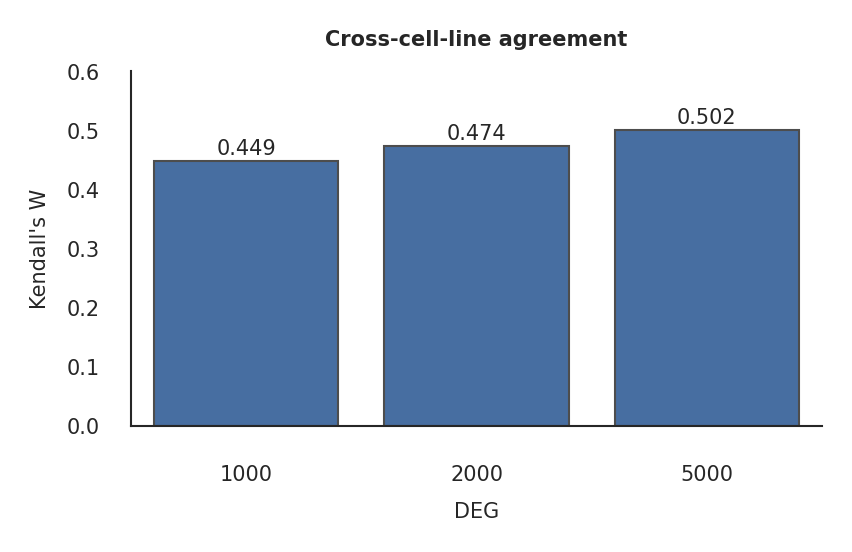

In [13]:
from scipy.stats import spearmanr, kendalltau
from scipy.cluster.hierarchy import linkage, dendrogram
import itertools

cell_lines = ['HCT116', 'HEK293T', 'K562', 'HepG2', 'Jurkat', 'RPE1']


# ── DEG=5000: correlation matrix heatmap with clustering ──
pivot = perturbation_analysis(new_metrics, method="trainMean", metric="spearman_distance_delta", deg=2000, top_n=10, agg_func='mean')
mat = pivot[cell_lines].dropna()

rho_mat = pd.DataFrame(np.ones((len(cell_lines), len(cell_lines))),
                        index=cell_lines, columns=cell_lines)
for a, b in itertools.combinations(cell_lines, 2):
    rho, p = spearmanr(mat[a], mat[b])
    rho_mat.loc[a, b] = rho
    rho_mat.loc[b, a] = rho

# Clustered heatmap
g = sns.clustermap(rho_mat, annot=True, fmt='.3f', cmap='RdYlBu_r',
                   vmin=0, vmax=1, linewidths=0.5,
                   figsize=(3, 3), dendrogram_ratio=0.15,
                   cbar_kws={'label': 'Spearman rho', 'shrink': 0.8},
                   method='average', metric='correlation',
                   annot_kws={'fontsize': 5})
g.ax_heatmap.set_title('Cross-cell-line correlation (DEG=5000)', fontsize=5, fontweight='bold', pad=10)
g.ax_heatmap.tick_params(labelsize=5)
cbar = g.ax_heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=5, length=0)
cbar.set_label('Spearman rho', fontsize=5)
# plt.savefig('plots/plot_cellline_corr_clustered.pdf', bbox_inches='tight', dpi=300)
plt.show()

# ── Kendall's W across DEG levels ──
w_records = []
for deg in [1000, 2000, 5000]:
    pivot_deg = perturbation_analysis(new_metrics, method="trainMean", metric="spearman_distance_delta", deg=deg, top_n=10, agg_func='mean')
    mat_deg = pivot_deg[cell_lines].dropna()
    
    ranks = mat_deg[cell_lines].rank(axis=0)
    n = len(ranks)
    k = len(cell_lines)
    rank_sums = ranks.sum(axis=1)
    S = ((rank_sums - rank_sums.mean()) ** 2).sum()
    W = 12 * S / (k**2 * (n**3 - n))
    w_records.append({'DEG': deg, 'W': W, 'n': n})

w_df = pd.DataFrame(w_records)

fig, ax = plt.subplots(figsize=(3, 2), dpi=300)
sns.set_theme(style='white')
sns.barplot(data=w_df, x='DEG', y='W', color='#386cb0', edgecolor='0.3', linewidth=0.5, ax=ax)
for i, row in w_df.iterrows():
    ax.text(i, row['W'] + 0.01, f'{row["W"]:.3f}', ha='center', fontsize=5)
ax.set_ylim(0, min(1, w_df['W'].max() + 0.1))
ax.set_xlabel('DEG', fontsize=5)
ax.set_ylabel("Kendall's W", fontsize=5)
ax.set_title("Cross-cell-line agreement", fontsize=5, fontweight='bold')
ax.tick_params(axis='x', rotation=0, labelsize=5)
ax.tick_params(axis='y', labelsize=5, direction='out', length=4, width=0.8)
sns.despine(ax=ax, top=True, right=True)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
plt.tight_layout()
# plt.savefig('plots/plot_kendall_w_by_deg.pdf', bbox_inches='tight', dpi=300)
plt.show()

Cell lines: ['HCT116', 'HEK293T', 'HepG2', 'Jurkat', 'K562', 'RPE1']
Common perturbations: 1912
Method=trainMean, Metric=spearman_distance_delta, DEG=2000
Cell lines: ['HCT116', 'HEK293T', 'HepG2', 'Jurkat', 'K562', 'RPE1']
Lower = better | n=1912 common perturbations

TOP 10 BEST PREDICTED (lowest spearman_distance_delta)
DataSet  HCT116  HEK293T   HepG2  Jurkat    K562    RPE1  mean_perf
perturb                                                            
RPL12    0.2494   0.3340  0.0781  0.2559  0.3782  0.0846     0.2300
UTP15    0.2326   0.3537  0.1662  0.1708  0.4185  0.0956     0.2396
MED21    0.3033   0.2556  0.1837  0.2223  0.2974  0.1830     0.2409
EXOSC9   0.1588   0.3622  0.2705  0.2235  0.3663  0.1090     0.2484
WDR75    0.1893   0.2943  0.1343  0.2366  0.5356  0.1260     0.2527
HEATR1   0.2098   0.3536  0.1260  0.2511  0.4174  0.1718     0.2549
EIF2B3   0.2273   0.2828  0.2866  0.3262  0.2226  0.2180     0.2606
EXOSC8   0.2022   0.4862  0.2618  0.2432  0.3131  0.1062     0.

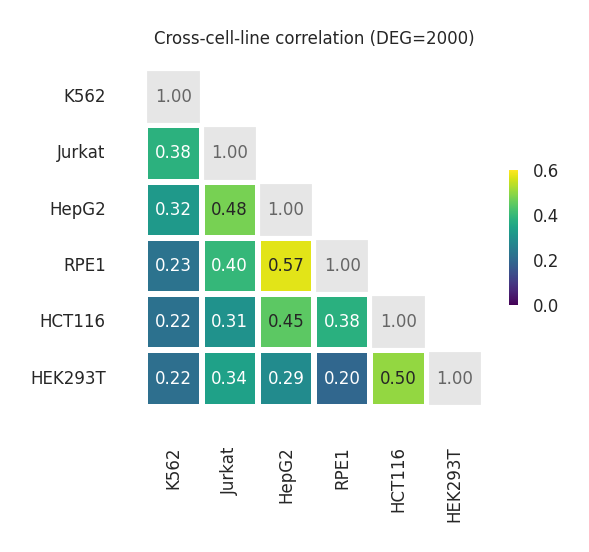

In [20]:
from scipy.stats import spearmanr, kendalltau
from scipy.cluster.hierarchy import linkage, dendrogram
import itertools

cell_lines_order = ['K562', 'Jurkat', 'HepG2', 'RPE1', 'HCT116', 'HEK293T']
# rename_map = {'hepg2': 'HepG2', 'jurkat': 'Jurkat', 'rpe1': 'RPE1'}

# ── DEG=2000: correlation matrix heatmap ──

pivot = perturbation_analysis(new_metrics1, method="trainMean", metric="spearman_distance_delta", deg=2000, top_n=10, agg_func='mean')
mat = 1 - pivot[cell_lines_order].dropna()


# Build correlation matrix
rho_mat = pd.DataFrame(np.ones((len(cell_lines_order), len(cell_lines_order))),
                        index=cell_lines_order, columns=cell_lines_order)
for a, b in itertools.combinations(cell_lines_order, 2):
    rho, _ = spearmanr(mat[a], mat[b])
    rho_mat.loc[a, b] = rho
    rho_mat.loc[b, a] = rho

# Use fixed order (no clustering)
rho_ordered = rho_mat

# Lower triangle mask (hide upper triangle + diagonal)
mask_lower = np.triu(np.ones_like(rho_ordered, dtype=bool))

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(2.5, 2), dpi=300)
sns.heatmap(rho_ordered, annot=True, fmt='.2f', cmap='viridis', ax=ax,
            mask=mask_lower, vmin=0.0, vmax=0.6,
            linewidths=1, linecolor='white', square=True,
            annot_kws={'fontsize': 4},
            cbar_kws={'shrink': 0.4, 'aspect': 15})

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=4, length=0)
cbar.set_label('')

n = len(cell_lines_order)
# Cover upper triangle with white
for i in range(n):
    for j in range(i + 1, n):
        ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color='white', lw=0))

# Draw grey diagonal cells with "1.00" text
for i in range(n):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, color='0.9', lw=1, ec='white'))
    ax.text(i + 0.5, i + 0.5, '1.00', ha='center', va='center', fontsize=4, color='0.4')

ax.set_title('Cross-cell-line correlation (DEG=2000)', fontsize=4)
ax.tick_params(labelsize=4)
plt.tight_layout()
if save_plot:
    plt.savefig('Fig1/Fig1C_plot_cellline_corr_clustered.png', bbox_inches='tight', dpi=300)
    plt.savefig('Fig1/Fig1C_plot_cellline_corr_clustered.svg', bbox_inches='tight')
plt.show()


In [24]:
cell_lines_order = ['K562', 'Jurkat', 'HepG2', 'RPE1', 'HCT116', 'HEK293T']

pivot = perturbation_analysis(new_metrics1, method="trainMean", metric="spearman_distance_delta", deg=2000, top_n=10, agg_func='mean')
mat = 1 - pivot[cell_lines_order].dropna()

# Build correlation and p-value matrices
rho_mat = pd.DataFrame(np.ones((len(cell_lines_order), len(cell_lines_order))),
                        index=cell_lines_order, columns=cell_lines_order)
pval_mat = pd.DataFrame(np.zeros((len(cell_lines_order), len(cell_lines_order))),
                        index=cell_lines_order, columns=cell_lines_order)
for a, b in itertools.combinations(cell_lines_order, 2):
    rho, pval = spearmanr(mat[a], mat[b])
    rho_mat.loc[a, b] = rho
    rho_mat.loc[b, a] = rho
    pval_mat.loc[a, b] = pval
    pval_mat.loc[b, a] = pval

# Print p-values
print("P-values:")
print(pval_mat.to_string())
print(f"P-values: min = {pval_mat.values[np.tril_indices(len(cell_lines_order), -1)].min():.2e}, "
      f"max = {pval_mat.values[np.tril_indices(len(cell_lines_order), -1)].max():.2e}")



Cell lines: ['HCT116', 'HEK293T', 'HepG2', 'Jurkat', 'K562', 'RPE1']
Common perturbations: 1912
Method=trainMean, Metric=spearman_distance_delta, DEG=2000
Cell lines: ['HCT116', 'HEK293T', 'HepG2', 'Jurkat', 'K562', 'RPE1']
Lower = better | n=1912 common perturbations

TOP 10 BEST PREDICTED (lowest spearman_distance_delta)
DataSet  HCT116  HEK293T   HepG2  Jurkat    K562    RPE1  mean_perf
perturb                                                            
RPL12    0.2494   0.3340  0.0781  0.2559  0.3782  0.0846     0.2300
UTP15    0.2326   0.3537  0.1662  0.1708  0.4185  0.0956     0.2396
MED21    0.3033   0.2556  0.1837  0.2223  0.2974  0.1830     0.2409
EXOSC9   0.1588   0.3622  0.2705  0.2235  0.3663  0.1090     0.2484
WDR75    0.1893   0.2943  0.1343  0.2366  0.5356  0.1260     0.2527
HEATR1   0.2098   0.3536  0.1260  0.2511  0.4174  0.1718     0.2549
EIF2B3   0.2273   0.2828  0.2866  0.3262  0.2226  0.2180     0.2606
EXOSC8   0.2022   0.4862  0.2618  0.2432  0.3131  0.1062     0.

In [22]:
# Build correlation and p-value matrices
rho_mat = pd.DataFrame(np.ones((len(cell_lines_order), len(cell_lines_order))),
                        index=cell_lines_order, columns=cell_lines_order)
p_mat = pd.DataFrame(np.zeros((len(cell_lines_order), len(cell_lines_order))),
                      index=cell_lines_order, columns=cell_lines_order)

for a, b in itertools.combinations(cell_lines_order, 2):
    rho, pval = spearmanr(mat[a], mat[b])
    rho_mat.loc[a, b] = rho
    rho_mat.loc[b, a] = rho
    p_mat.loc[a, b] = pval
    p_mat.loc[b, a] = pval

print(p_mat)


                  K562         Jurkat          HepG2           RPE1  \
K562      0.000000e+00  3.000064e-104   1.955981e-72   8.210919e-44   
Jurkat   3.000064e-104   0.000000e+00  7.298895e-153  6.692794e-115   
HepG2     1.955981e-72  7.298895e-153   0.000000e+00  4.589193e-220   
RPE1      8.210919e-44  6.692794e-115  4.589193e-220   0.000000e+00   
HCT116    3.058235e-30   1.176366e-51  2.972532e-104   7.966724e-78   
HEK293T   5.699659e-26   3.089432e-56   9.377430e-42   5.980020e-23   

                HCT116        HEK293T  
K562      3.058235e-30   5.699659e-26  
Jurkat    1.176366e-51   3.089432e-56  
HepG2    2.972532e-104   9.377430e-42  
RPE1      7.966724e-78   5.980020e-23  
HCT116    0.000000e+00  3.145573e-147  
HEK293T  3.145573e-147   0.000000e+00  


Cell lines: ['HCT116', 'HEK293T', 'HepG2', 'Jurkat', 'K562', 'RPE1']
Common perturbations: 1912
Cell lines: ['HCT116', 'HEK293T', 'HepG2', 'Jurkat', 'K562', 'RPE1']
Common perturbations: 1912
Cell lines: ['HCT116', 'HEK293T', 'HepG2', 'Jurkat', 'K562', 'RPE1']
Common perturbations: 1912


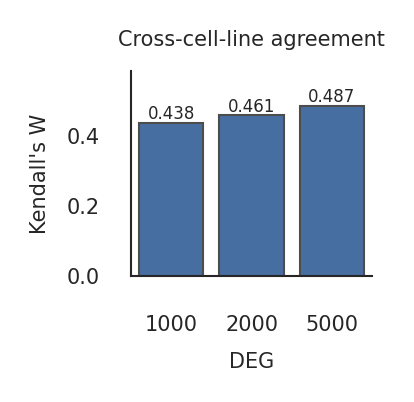

In [25]:
from scipy.stats import spearmanr
import itertools

cell_lines_order = ['K562', 'Jurkat', 'HepG2', 'RPE1', 'HCT116', 'HEK293T']
rename_map = {'hepg2': 'HepG2', 'jurkat': 'Jurkat', 'rpe1': 'RPE1'}

w_records = []
for deg in [1000, 2000, 5000]:
    pivot_deg = perturbation_analysis(new_metrics1, method="trainMean", metric="spearman_distance_delta", deg=deg, top_n=10, agg_func='mean', verbose=False)
    mat_deg = pivot_deg[cell_lines_order].dropna()

    
    ranks = mat_deg[cell_lines_order].rank(axis=0)
    n = len(ranks)
    k = len(cell_lines_order)
    rank_sums = ranks.sum(axis=1)
    S = ((rank_sums - rank_sums.mean()) ** 2).sum()
    W = 12 * S / (k**2 * (n**3 - n))
    w_records.append({'DEG': deg, 'W': W, 'n': n})

w_df = pd.DataFrame(w_records)

fig, ax = plt.subplots(figsize=(1.5, 1.5), dpi=300)
sns.set_theme(style="white")
sns.barplot(data=w_df, x='DEG', y='W', color='#386cb0', edgecolor='0.3', linewidth=0.5, ax=ax)
for i, row in w_df.iterrows():
    ax.text(i, row['W'] + 0.01, f'{row["W"]:.3f}', ha='center', fontsize=4)
ax.set_ylim(0, min(1, w_df['W'].max() + 0.1))
ax.set_xlabel('DEG', fontsize=5)
ax.set_ylabel("Kendall's W", fontsize=5)
ax.set_title("Cross-cell-line agreement", fontsize=5)
ax.tick_params(axis='x', rotation=0, labelsize=5)
ax.tick_params(axis='y', labelsize=5, direction='out', length=4, width=0.8)
sns.despine(ax=ax, top=True, right=True)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

plt.tight_layout()
if save_plot:
    plt.savefig('Fig1/Fig1D_kendall_w.png', bbox_inches='tight', dpi=300)
    plt.savefig('Fig1/Fig1D_kendall_w.svg', bbox_inches='tight')
plt.show()
